[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rafelsalgueiro/GallegoSalgueiroVera/blob/main/k_brazos/estudio_binomial.ipynb)

# Estudio completo del problema de k-armed bandit con brazos Binomiales

*Description:* Este notebook realiza un estudio exhaustivo del problema de k-armed bandit utilizando brazos con distribución Binomial. Se comparan los siguientes algoritmos:

- *Epsilon-Greedy y Epsilon-Decay* (con distintos valores de ε)
- *UCB1* (con distintos valores de c)
- *Softmax* (con distintas temperaturas τ)

Se analizan métricas de regret acumulado y porcentaje de selección óptima, y se incluye un experimento final de comparación directa entre los tres algoritmos.

 #### El Problema Multi-Armed Bandit
El problema consiste en un agente que debe elegir repetidamente entre k opciones (brazos). Cada opción proporciona una recompensa extraída de una distribución de probabilidad desconocida para esa opción. El objetivo es maximizar la recompensa total (o minimizar el regret acumulado) a lo largo de un horizonte temporal $T$.

En este caso, usamos brazos Binomiales, donde la recompensa representa el número de éxitos normalizado tras realizar $n$ ensayos independientes, cada uno con una probabilidad de éxito $p$. Dado que normalizamos la recompensa dividiendo por $n$, el valor esperado de un brazo es simplemente su probabilidad de éxito $p$.

```
Authors: Gallego, Salgueiro y Vera.
Date: 2026/02/16
```

## 1. Preparación del entorno
A continuación están todos los requisitos Python para este estudio, importándose las librerías necesarias.

In [ ]:
!git clone https://github.com/rafelsalgueiro/GallegoSalgueiroVera.git

In [ ]:
!pip install matplotlib numpy seaborn

In [ ]:
!cd GallegoSalgueiroVera/k_brazos && pwd

In [4]:
import sys
import os

import numpy as np
import matplotlib.pyplot as plt

project_root = os.path.abspath('GallegoSalgueiroVera/k_brazos')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

try:
    from src.agents import *
    from src.arms import BinomialArm, Bandit
    from src.plotting import *
    print("Entorno cargado correctamente.")

except ImportError as e:
    print(f"Error cargando el entorno: {e}")
    sys.exit(1)
    
# Parámetros del experimento
seed = 42
np.random.seed(seed)  # Fijar la semilla para reproducibilidad

Entorno cargado correctamente.


## 2. Definición del bucle experimental
La función `run_experiment` ejecuta cada algoritmo sobre el mismo conjunto de brazos Binomiales durante `n_steps` pasos, repitiendo el proceso `n_runs` veces para obtener resultados promediados.

Se calculan dos métricas:

- **Regret acumulado:** diferencia acumulada entre la recompensa esperada del brazo óptimo y la del brazo seleccionado.
- **Selección óptima:** proporción de veces que se selecciona el brazo con mayor valor esperado.

In [5]:
def run_experiment(bandit: Bandit, agents: list[Agent], steps: int, runs: int):
    optimal_arm_idx, optimal_value = bandit.get_optimal_arm()
    rewards = np.zeros((len(agents), steps))
    optimal_selections = np.zeros((len(agents), steps))

    for run in range(runs):
        current_bandit = Bandit(bandit.arms)
        for agent in agents:
            agent.reset()

        for step in range(steps):
            for idx, agent in enumerate(agents):
                action = agent.get_action()
                reward = current_bandit.pull_arm(action)
                agent.update(action, reward)

                rewards[idx, step] += reward

                if action == optimal_arm_idx:
                    optimal_selections[idx, step] += 1
            
    rewards /= runs
    optimal_selections /= runs
    return rewards, optimal_selections

## 3. Configuración de los brazos Binomiales

Definimos un bandido de 10 brazos con distintas probabilidades de éxito. El brazo con p = 0.9 es el óptimo.

In [6]:
steps = 1000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones
k = 10 # Número de brazos
# Creación del bandit
bandit = Bandit(arms=BinomialArm.generate_arms(k, min_p=0.1, max_p=0.9))

# Constante teórica de Lai-Robbins para la cota inferior del regret
lai_robbins_cte = bandit.get_theoretical_constant()

def show_bandit_info(bandit: Bandit, title: str):
    print(f"--- {title} ---")
    print(bandit)
    # Obtenemos el índice y valor del brazo óptimo desde el objeto bandit
    optimal_arm_idx, optimal_value = bandit.optimal_arm
    print(f"Brazo óptimo: {optimal_arm_idx} con media {optimal_value:.4f}")
    print(f"Constante de Lai-Robbins: {lai_robbins_cte:.4f}")

show_bandit_info(bandit, "Bandit Binomial")

--- Bandit Binomial ---
Bandit with 10 arms: ArmBinomial(n=10, p=0.1), ArmBinomial(n=10, p=0.18888888888888888), ArmBinomial(n=10, p=0.2777777777777778), ArmBinomial(n=10, p=0.3666666666666667), ArmBinomial(n=10, p=0.4555555555555556), ArmBinomial(n=10, p=0.5444444444444445), ArmBinomial(n=10, p=0.6333333333333333), ArmBinomial(n=10, p=0.7222222222222222), ArmBinomial(n=10, p=0.8111111111111111), ArmBinomial(n=10, p=0.9)
Brazo óptimo: 9 con media 0.9000
Constante de Lai-Robbins: 0.8698


### 4. Epsilon-Greedy y Epsilon-Decay con distintos valores de ε
#### Teoría: Epsilon-Greedy
El algoritmo Epsilon-Greedy es una de las estrategias más simples para equilibrar exploración y explotación:

- Con probabilidad $1- ε$, explotamos: elegimos el brazo con mayor valor estimado promedio hasta el momento.
- Con probabilidad $ε$, exploramos: elegimos un brazo aleatorio uniformemente. Un $\epsilon$ alto favorece el descubrimiento rápido pero impide converger completamente al óptimo a largo plazo. Un $\epsilon$ bajo es más eficiente a largo plazo, pero su aprendizaje es muy lento al inicio.

#### Teoría: Epsilon-Decay (Decaimiento)
Para solucionar la limitación del parámetro estático, se introduce la variante con decaimiento. Esta estrategia permite un aprendizaje dinámico: comienza con una exploración total ($\epsilon_{start} = 1.0$) para evaluar todas las opciones rápidamente, y disminuye progresivamente este valor en cada paso hasta estabilizarse en un mínimo ($\epsilon_{end}$). La velocidad de esta reducción está determinada por la tasa de decaimiento ($\lambda$).

Comparamos tres configuraciones del algoritmo Epsilon-Greedy:

- `ε = 0.0` (puramente voraz, sin exploración)
- `ε = 0.01` (exploración mínima)
- `ε = 0.1` (exploración moderada)
- `ε = 0.3` (exploración alta)

Variantes dinámicas (Epsilon-Decay):
Todas las variantes dinámicas inician con $\epsilon = 1.0$ y tienen un tope mínimo de $\epsilon = 0.01$, variando únicamente su velocidad de enfriamiento:
- `λ = 0.01`: Decaimiento lento.
- `λ = 0.05`: Decaimiento moderado.
- `λ = 0.1`: Decaimiento rápido.

A través de la función `run_experiment`, estos siete agentes se someten a múltiples ejecuciones sobre el mismo bandido. Posteriormente, extraemos tanto las recompensas promedio como el porcentaje de selecciones óptimas de cada agente para compararlos con el valor esperado real del mejor brazo del entorno.

In [7]:
# Definir los algoritmos a comparar. En este caso son 4 algoritmos epsilon-greedy con diferentes valores de epsilon.
agents_e = [
    EpsilonGreedyAgent(k, epsilon=0.0),
    EpsilonGreedyAgent(k, epsilon=0.01),
    EpsilonGreedyAgent(k, epsilon=0.1),
    EpsilonGreedyAgent(k, epsilon=0.3),
    EpsilonDecayAgent(k_arms=k, e_start=1.0, e_end=0.01, lda=0.01),
    EpsilonDecayAgent(k_arms=k, e_start=1.0, e_end=0.01, lda=0.05),
    EpsilonDecayAgent(k_arms=k, e_start=1.0, e_end=0.01, lda=0.1)
]

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards_e, optimal_selections_e = run_experiment(bandit, agents_e, steps, runs)

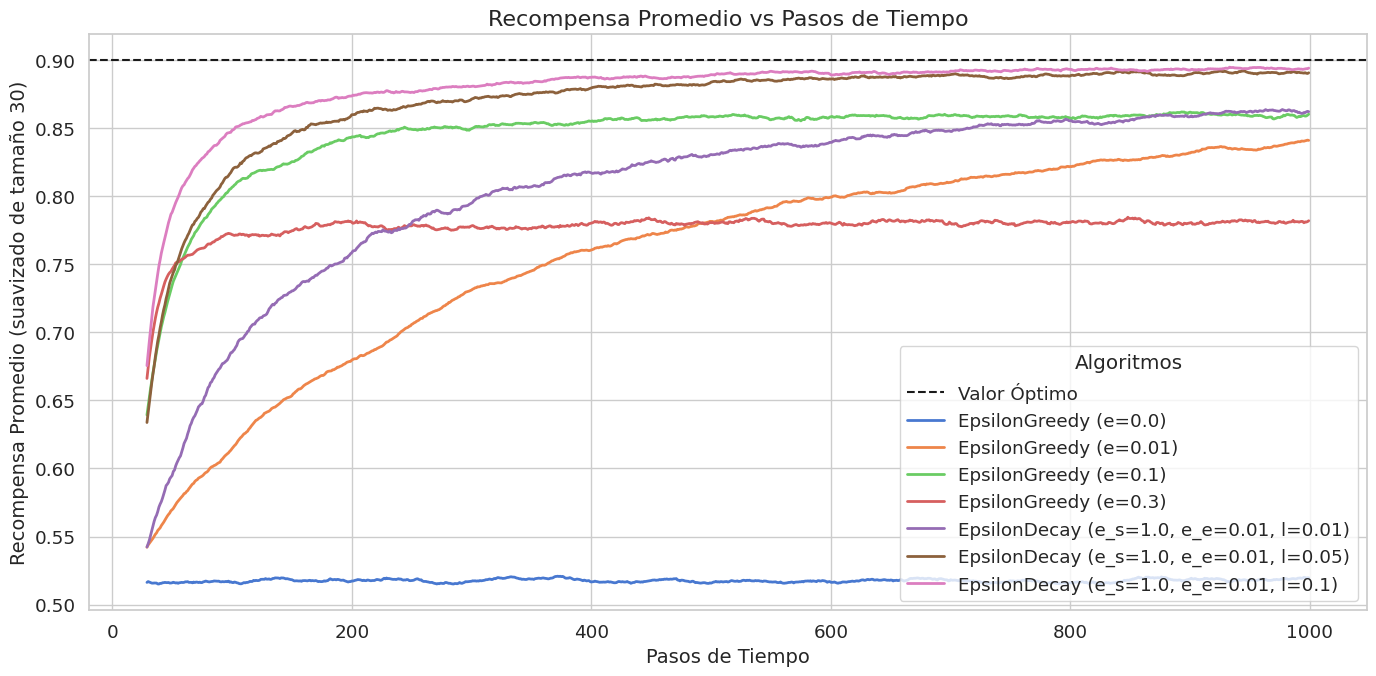

In [8]:
_, optimal_value = bandit.optimal_arm
plot_average_rewards(steps, rewards_e, agents_e, optimal_value=optimal_value, window_size=30)

Véase cómo en la gráfica de recompensa promedio se puede observar claramente la influencia del parámetro ε en la velocidad de aprendizaje del agente.

Un ε nulo (ε = 0) provoca que el agente explote desde el inicio la primera estimación obtenida, lo que hace que la recompensa promedio permanezca prácticamente constante y en un nivel bajo, al no corregir posibles errores iniciales.

Cuando ε es pequeño (ε = 0.01), el crecimiento de la recompensa es progresivo pero lento, ya que la exploración es limitada y el descubrimiento del brazo óptimo tarda más tiempo.

Con ε = 0.1, se aprecia una convergencia más rápida hacia valores altos de recompensa promedio, debido a que el agente explora lo suficiente como para identificar el mejor brazo y posteriormente explotarlo con alta probabilidad.

Sin embargo, un ε elevado (ε = 0.3) muestra una mejora rápida inicial, pero se estabiliza en valores inferiores al óptimo, ya que la exploración constante impide una explotación completa.

En el caso de ε-Decay, se observa que comenzar con alta exploración y reducirla progresivamente permite alcanzar las mayores recompensas promedio, combinando descubrimiento temprano y explotación eficiente a largo plazo.

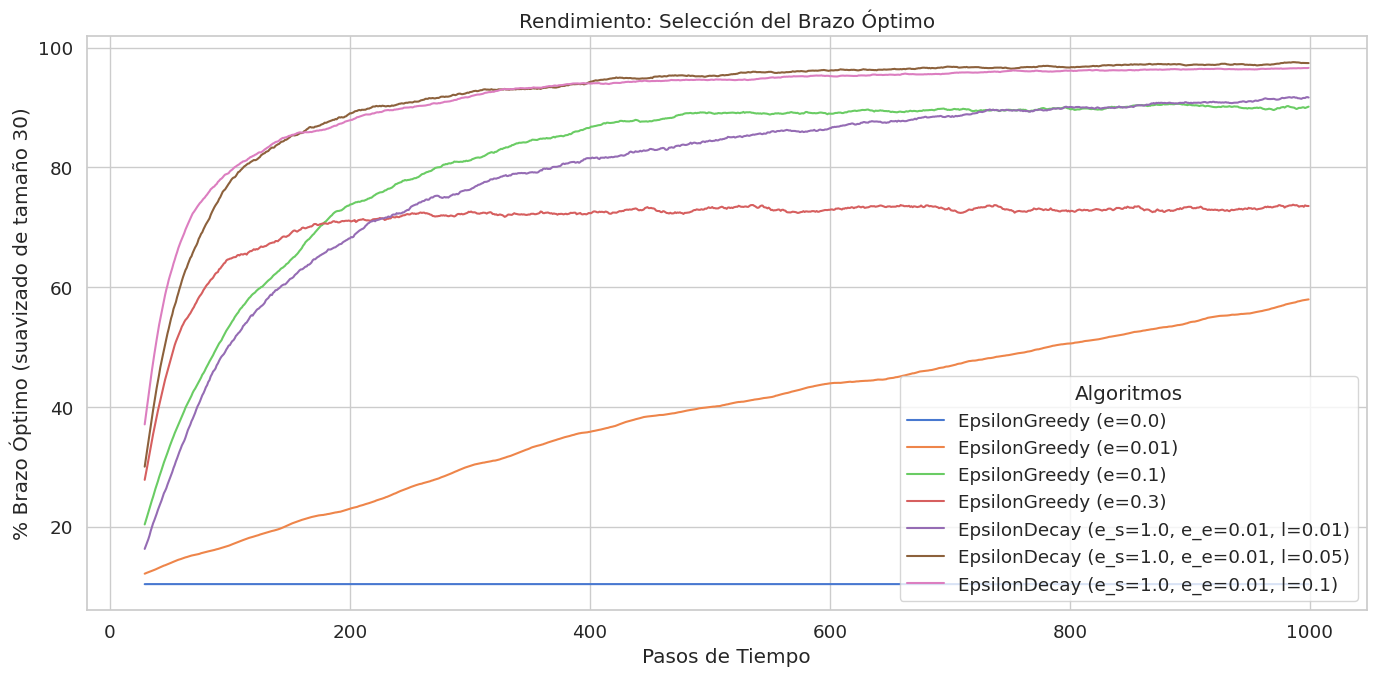

In [9]:
# Gráfica de selección óptima para Epsilon-Greedy
plot_optimal_selections(steps, optimal_selections_e, agents_e, window_size=30)

Véase cómo en la gráfica de selección del brazo óptimo se refleja de forma directa la eficiencia de cada política de exploración.

Con ε = 0, el porcentaje de selección del brazo óptimo permanece cercano al azar inicial, evidenciando la incapacidad del agente para corregir decisiones erróneas.

Para ε = 0.01, la proporción de selección óptima aumenta gradualmente, aunque de forma lenta, debido a la baja tasa de exploración.

Con ε = 0.1, se observa una rápida convergencia hacia valores altos de selección óptima, mostrando un equilibrio adecuado entre exploración y explotación.

Cuando ε = 0.3, el crecimiento inicial es rápido, pero el porcentaje se estabiliza en valores inferiores, dado que la exploración constante limita la explotación del brazo óptimo.

En contraste, las estrategias ε-Decay alcanzan los mayores porcentajes de selección óptima, ya que permiten una fase inicial de descubrimiento seguida de una explotación predominante, maximizando el rendimiento a largo plazo.

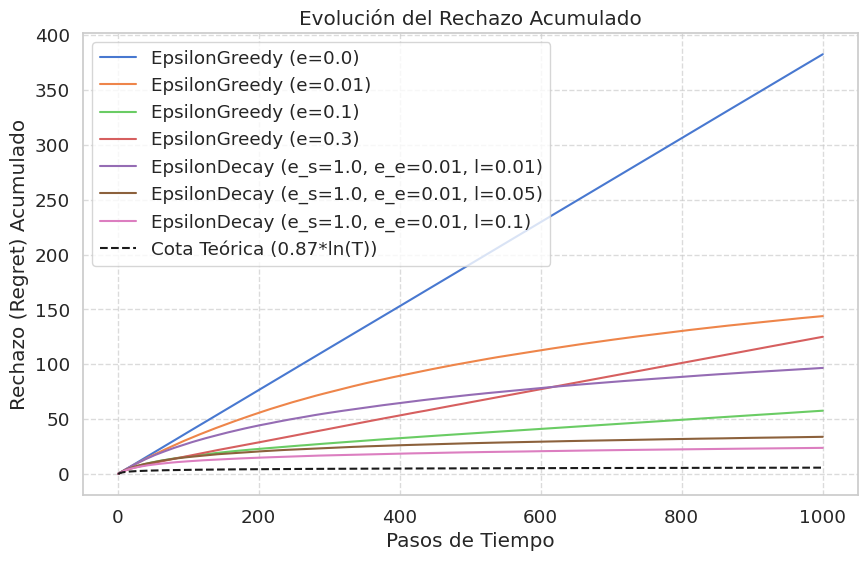

In [10]:
_, optimal_value = bandit.optimal_arm
regret_per_step = optimal_value - rewards_e
cumulative_regret = np.cumsum(regret_per_step, axis=1)

plot_regret(steps, cumulative_regret, agents_e, cte=lai_robbins_cte)

Véase cómo en la gráfica de arrepentimiento acumulado se aprecia el impacto directo del parámetro ε sobre el coste total de exploración.

Un ε = 0 genera un crecimiento prácticamente lineal del arrepentimiento, ya que si el agente selecciona un brazo subóptimo al inicio, continuará explotándolo indefinidamente.

Con ε pequeños (0.01), el crecimiento del arrepentimiento sigue siendo lineal, pero ligeramente menor, ya que la exploración ocasional permite corregir decisiones erróneas.

Cuando ε = 0.1, el agente incurre en un mayor coste inicial debido a la exploración, pero logra reducir el arrepentimiento relativo a largo plazo al identificar el brazo óptimo con mayor probabilidad.

Para ε = 0.3, el arrepentimiento acumulado aumenta más rápidamente, puesto que la exploración constante implica seleccionar brazos subóptimos con mayor frecuencia.

En las estrategias ε-Decay, el crecimiento del arrepentimiento es más controlado: el agente explora intensamente al principio (cuando la incertidumbre es mayor) y reduce progresivamente el coste acumulado al explotar casi exclusivamente el brazo óptimo en etapas posteriores.

### Análisis de Resultados (Epsilon-Greedy y Epsilon-Decay)

Observamos los siguientes comportamientos característicos a partir de las tres métricas analizadas (recompensa promedio, selección óptima y regret acumulado):

Greedy ($\epsilon=0$):
Se estanca desde el inicio. Al no explorar, depende completamente de las primeras muestras obtenidas. Si inicialmente selecciona un brazo subóptimo, continuará explotándolo indefinidamente. Esto se traduce en una recompensa promedio baja, un porcentaje de selección óptima cercano al azar y un crecimiento lineal del regret acumulado.

$\epsilon=0.01$ (exploración baja constante):
Converge lentamente. La exploración limitada le permite eventualmente descubrir el brazo óptimo, pero el proceso es progresivo y tarda muchos pasos en estabilizarse. A largo plazo mejora claramente respecto a greedy, aunque su velocidad de aprendizaje es reducida.

$\epsilon=0.1$ (exploración moderada constante):
Representa el mejor equilibrio entre exploración y explotación dentro de los valores constantes. Aprende con rapidez cuál es el mejor brazo y alcanza altos porcentajes de selección óptima. Sin embargo, su regret continúa creciendo de forma lineal, ya que siempre dedica un 10% de las decisiones a explorar, incluso cuando ya ha identificado el óptimo.

$\epsilon=0.3$ (exploración alta constante):
Aprende muy rápido al principio, mostrando una subida pronunciada en la selección del brazo óptimo. No obstante, su rendimiento se estanca en niveles inferiores, ya que explora demasiado de forma permanente, lo que limita la explotación del mejor brazo y aumenta el regret acumulado.

Epsilon-Decay ($\epsilon$ decreciente):
Combina lo mejor de ambos enfoques. Comienza con una exploración elevada (favoreciendo el descubrimiento temprano del brazo óptimo) y reduce progresivamente $\epsilon$, aumentando la explotación a medida que el agente adquiere información fiable.
Como resultado:

- Presenta la mayor recompensa promedio final.
- Alcanza los porcentajes más altos de selección óptima.
- Mantiene el regret acumulado más bajo a largo plazo.

La velocidad de decaimiento es clave: un decaimiento más rápido permite una transición temprana hacia la explotación, mientras que uno más lento prolonga la fase exploratoria.

## 5. UCB1 con distintos valores de c

### Teoría: UCB1 (Upper Confidence Bound)

UCB1 sigue el principio de \"optimismo ante la incertidumbre\". En lugar de usar una aleatoriedad fija como Epsilon-Greedy, UCB1 calcula un índice de confianza para cada brazo y elige el que tiene el límite superior más alto:

$$ A_t = \arg\max_a \left[ Q_t(a) + c \sqrt{\frac{\ln t}{N_t(a)}} \right] $$

- El primer término $Q_t(a)$ fomenta la explotación (brazos con buen promedio).
- El segundo término fomenta la exploración de brazos poco visitados (donde $N_t(a)$ es pequeño).
- A medida que el tiempo $t$ avanza, el término de exploración decrece, permitiendo que el algoritmo converja naturalmente al brazo óptimo sin necesidad de reducir un parámetro manualmente.

El parámetro `c` controla el grado de exploración en la fórmula UCB1:

$$Q(a) + c \cdot \sqrt{\frac{\ln(t)}{N(a)}}$$

Comparamos:
- `c = 0.5` (exploración conservadora)
- `c = 1.0` (exploración moderada)
- `c = 2.0` (exploración estándar)
- `c = 4.0` (exploración agresiva)

In [11]:
# Definir agentes UCB1 con distintos parámetros c
agents_ucb = [
    UCBAgent(k_arms=k, c=0.5), 
    UCBAgent(k_arms=k, c=1.0), 
    UCBAgent(k_arms=k, c=2.0), 
    UCBAgent(k_arms=k, c=4.0)
]

rewards_ucb, optimal_selections_ucb = run_experiment(bandit, agents_ucb, steps, runs)

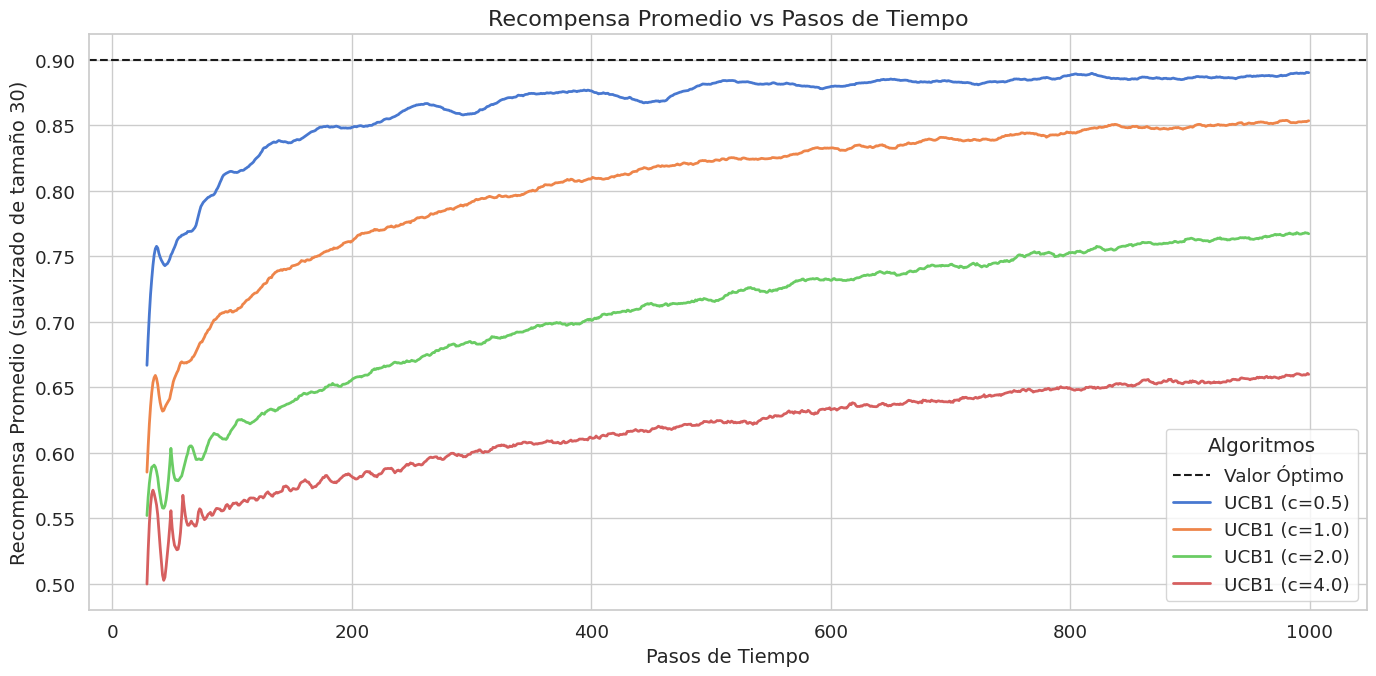

In [12]:
_, optimal_value = bandit.optimal_arm
plot_average_rewards(steps, rewards_ucb, agents_ucb, optimal_value=optimal_value, window_size=30)

En esta gráfica se observa cómo influye el parámetro 𝑐 en la calidad del aprendizaje del algoritmo UCB1.
- c = 0.5 (azul): Es el que alcanza más rápidamente valores cercanos al óptimo. La recompensa promedio crece con rapidez y se estabiliza prácticamente en el valor máximo. Esto indica un equilibrio muy eficiente entre exploración y explotación.
- c = 1.0 (naranja): Converge de forma estable, aunque ligeramente más lento que 𝑐=0.5. Se aproxima bastante al valor óptimo, pero mantiene pequeñas oscilaciones debido a mayor exploración.
- c = 2.0 (verde): El crecimiento es más gradual. La exploración más intensa retrasa la convergencia y la recompensa promedio final es inferior a los valores anteriores.
- c = 4.0 (rojo): Presenta la convergencia más lenta y la recompensa promedio más baja. La exploración excesiva impide consolidar la explotación del brazo óptimo.

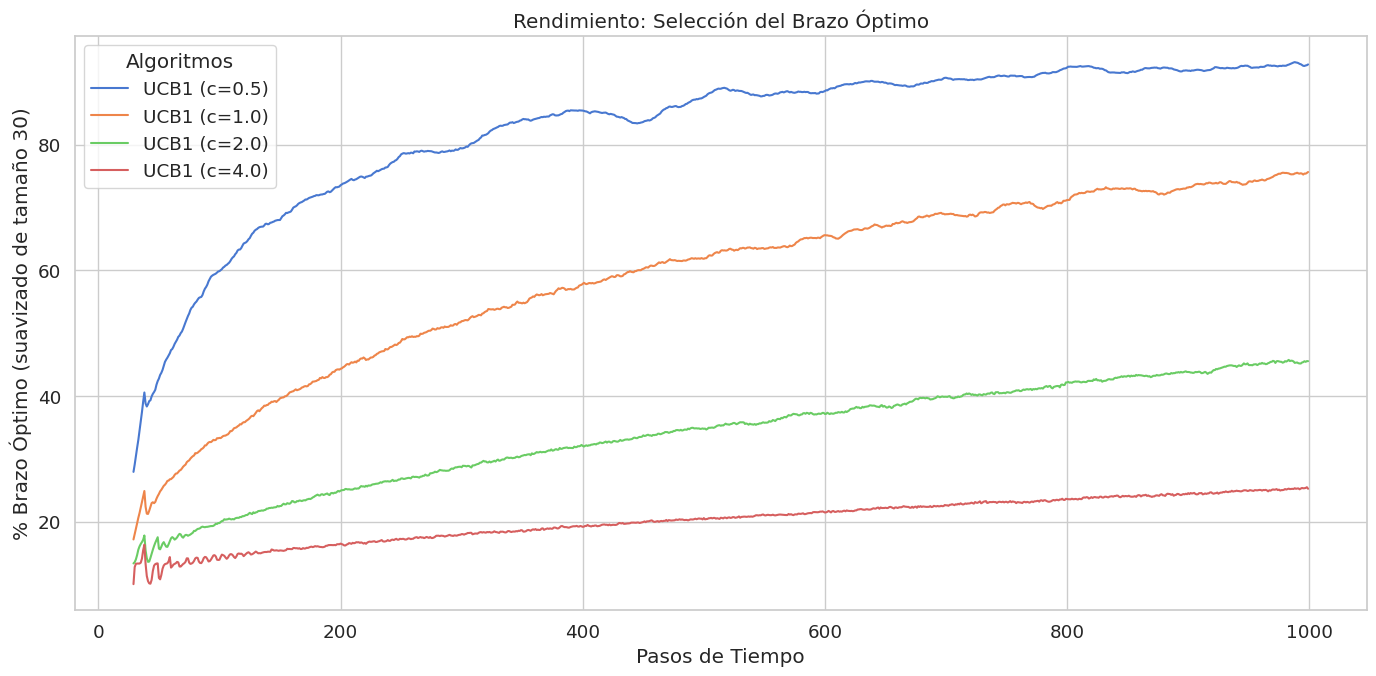

In [13]:
plot_optimal_selections(steps, optimal_selections_ucb, agents_ucb, window_size=30)

Aquí se aprecia claramente el impacto del parámetro 𝑐 en la capacidad de identificar el mejor brazo.
- c = 0.5: Rápida convergencia hacia porcentajes superiores al 90%. Es el más eficiente.
- c = 1.0: Buena convergencia, aunque más progresiva.
- c = 2.0: Incremento lento y sostenido, sin alcanzar valores cercanos al óptimo dentro del horizonte temporal.
- c = 4.0: Crecimiento muy lento. La exploración excesiva impide consolidar la selección óptima.

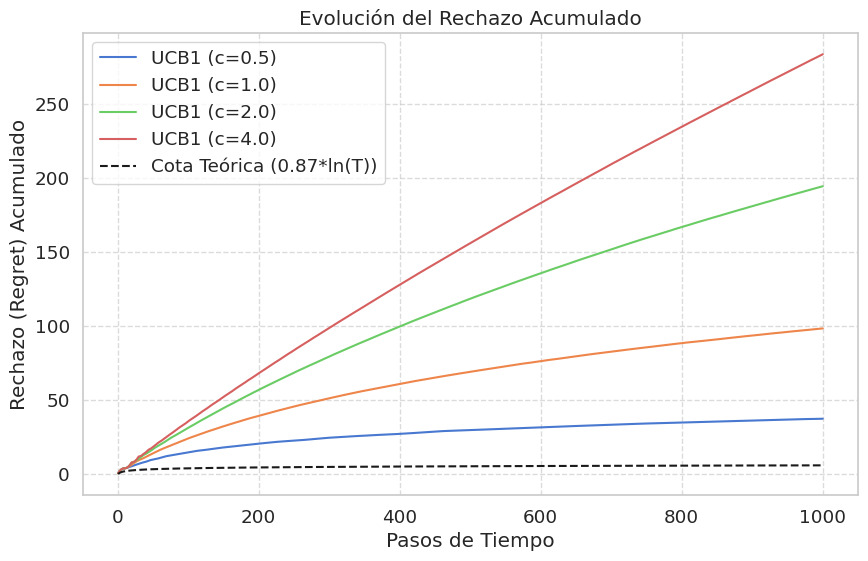

In [14]:
_, optimal_value = bandit.optimal_arm
regret_per_step = optimal_value - rewards_ucb
cumulative_regret = np.cumsum(regret_per_step, axis=1)

plot_regret(steps, cumulative_regret, agents_ucb, cte=lai_robbins_cte)

En esta gráfica se analiza el coste acumulado de no seleccionar siempre el brazo óptimo.
- Todas las curvas presentan crecimiento aproximadamente lineal.
- Las diferencias entre valores de 𝑐 son relativamente pequeñas.
- Valores mayores de 𝑐 (más exploración) muestran un regret ligeramente superior.

### Análisis de Resultados (UCB1)

1. **Estabilidad:** En contraste con Epsilon-Greedy, UCB1 demuestra ser un algoritmo mucho más sólido y consistente. Su principal ventaja es que funciona adecuadamente de forma natural, sin exigir una calibración de parámetros tan minuciosa.
2. **Convergencia:** El modelo consigue localizar la mejor acción y, lo que es fundamental, disminuye progresivamente su necesidad de explorar. Este comportamiento queda reflejado en su curva de regret, la cual presenta un crecimiento logarítmico (más atenuado) en lugar de un aumento lineal constante.
3. **Impacto de $c$:** Configurar el parámetro c con cifras elevadas (como 4.0) induce un exceso de exploración en los primeros pasos, asimilándose a una selección puramente al azar. Por el contrario, utilizar valores reducidos acelera la convergencia, aunque conlleva el peligro de descartar prematuramente la mejor opción si se obtienen bajas recompensas al principio.

## 6. Softmax con distintas temperaturas $τ$
### Teoría: Softmax (Boltzmann Exploration)
El algoritmo **Softmax** elige brazos probabilísticamente, donde la probabilidad de elegir un brazo es proporcional a su valor estimado. Se usa la distribución de Boltzmann:
$$ P(a) = \frac{e^{Q_t(a)/\tau}}{\sum_{b=1}^k e^{Q_t(b)/\tau}} $$

- Si $\tau \to \infty$, las probabilidades tienden a ser uniformes (exploración pura).
- Si $\tau \to 0$, la probabilidad se concentra en el brazo con mayor valor (explotación pura / Greedy).

La ventaja sobre Epsilon-Greedy es que cuando explora, prefiere brazos \"prometedores\" (segundos mejores) sobre los claramente malos, en lugar de elegir cualquiera al azar.
"El parámetro $\tau$ (temperatura) controla la distribución de probabilidad de selección:
- $\tau$ bajo: El agente es más decisivo (concentra la probabilidad en el brazo con mayor Q estimado).
- $\tau$ alto: Las probabilidades se igualan, generando exploración uniforme.

Comparamos:
- `τ = 0.01` (casi determinista)
- `τ = 0.1` (selectivo)
- `τ = 0.5` (moderado)
- `τ = 1.0` (más uniforme)

In [15]:
# Definir los algoritmos a comparar. En este caso son 4 algoritmos softmax con diferentes valores de temperatura.
agents_soft = [SoftmaxAgent(k_arms=k, temperature=0.01), 
          SoftmaxAgent(k_arms=k, temperature=0.1), 
          SoftmaxAgent(k_arms=k, temperature=0.5), 
          SoftmaxAgent(k_arms=k, temperature=1.0)
]

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards_soft, optimal_selections_soft = run_experiment(bandit, agents_soft, steps, runs)

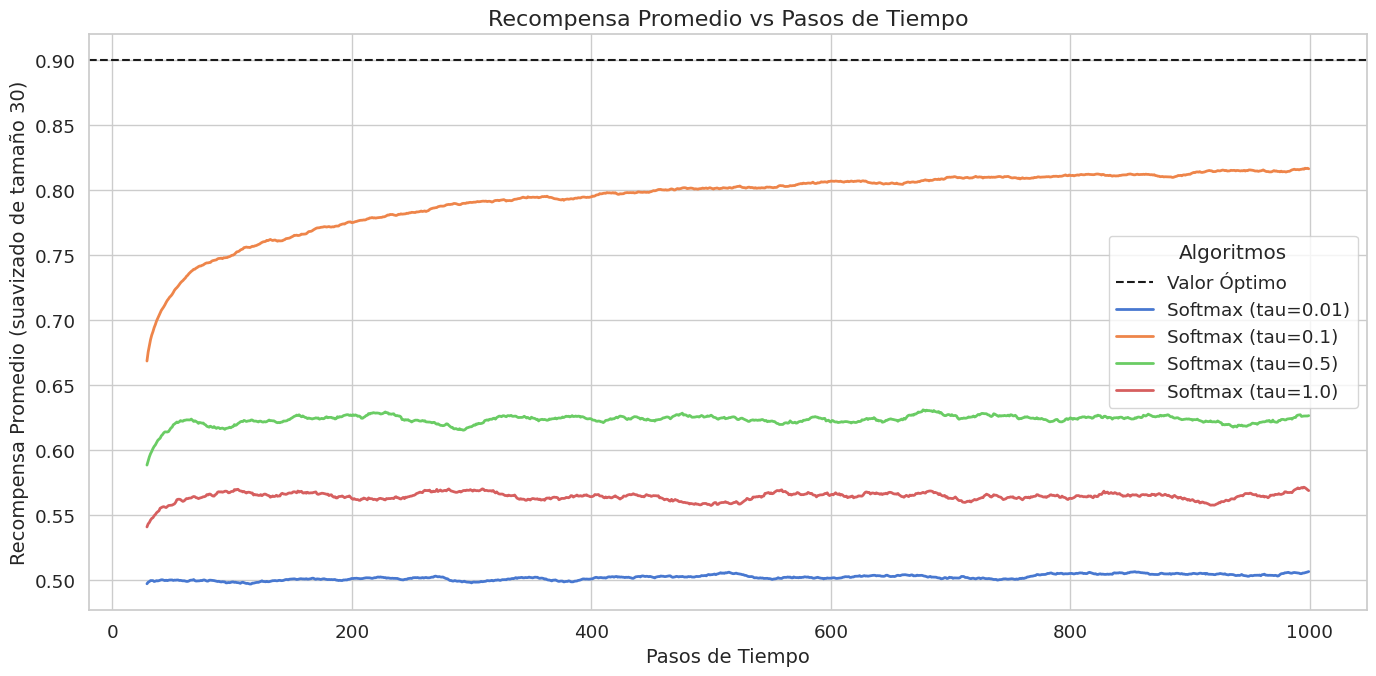

In [16]:
_, optimal_value = bandit.optimal_arm
plot_average_rewards(steps, rewards_soft, agents_soft, optimal_value=optimal_value, window_size=30)

Aquí el parámetro clave es la temperatura τ, que controla qué tan “suaves” son las probabilidades de selección.
- τ = 0.01 (azul): La recompensa se mantiene baja (~0.58). Con una temperatura tan pequeña, el algoritmo se vuelve casi determinista desde el inicio y deja de explorar demasiado pronto. Si no identifica correctamente el brazo óptimo al principio, queda atrapado en una mala elección.
- τ = 0.1 (naranja): Es claramente el mejor desempeño. La recompensa crece rápidamente y se acerca al valor óptimo (~0.9). Logra un excelente equilibrio entre exploración inicial y explotación posterior.
- τ = 0.5 (verde): La recompensa se estabiliza alrededor de ~0.69. Aquí la exploración es mayor y el aprendizaje es más lento.
- τ = 1.0 (rojo): Rendimiento aún menor (~0.60). La exploración es demasiado alta, lo que impide concentrarse suficientemente en el mejor brazo.

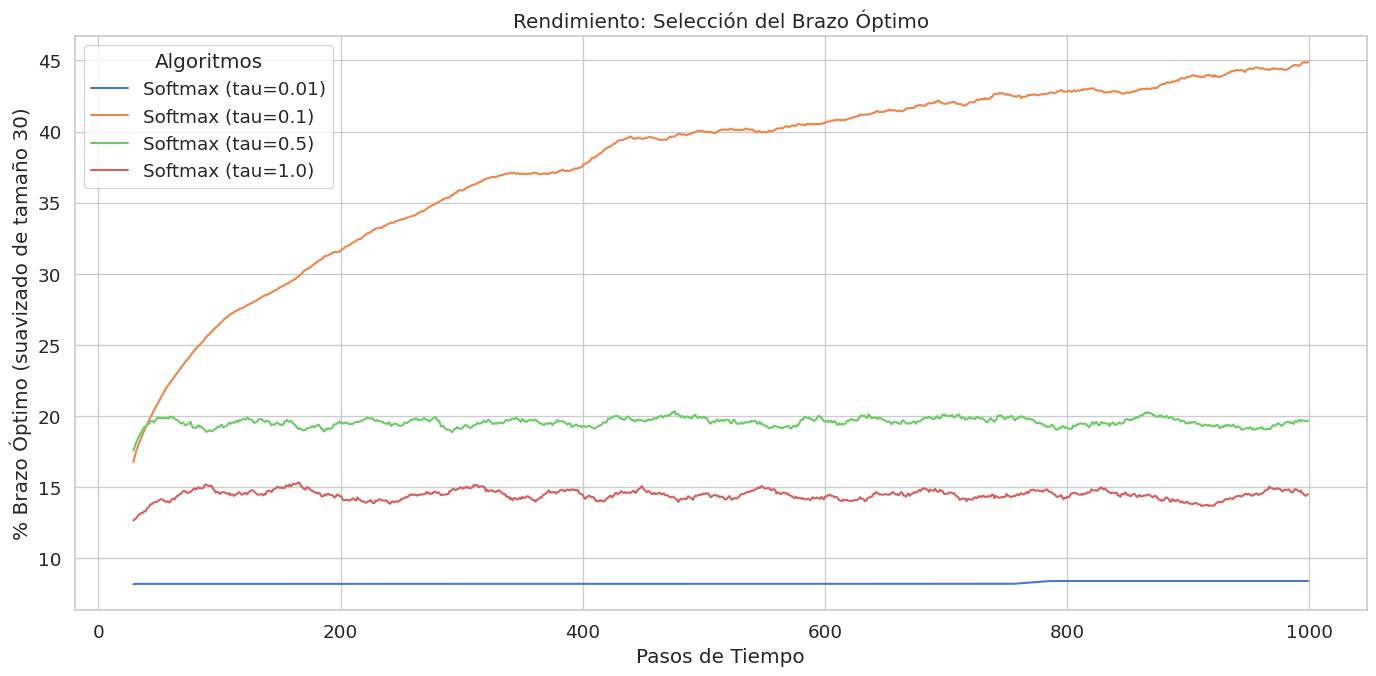

In [17]:
plot_optimal_selections(steps, optimal_selections_soft, agents_soft, window_size=30)

Aquí se ve con mucha claridad el efecto de τ:
- τ = 0.1: Incremento constante hasta superar el 40% de selección óptima. Es el que mejor identifica el brazo correcto.
- τ = 0.5: Se mantiene alrededor del 22–23%. Explora demasiado para consolidar la mejor opción.
- τ = 1.0: Apenas alcanza ~16%. Mucha exploración, poca especialización.
- τ = 0.01: Se queda estancado cerca del 11%. Casi no mejora porque explota prematuramente.

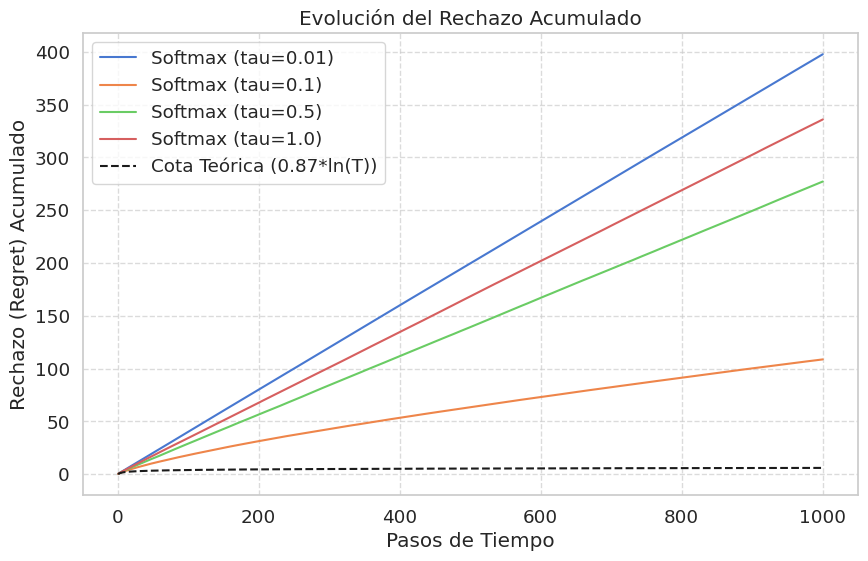

In [18]:
_, optimal_value = bandit.optimal_arm
regret_per_step = optimal_value - rewards_soft
cumulative_regret = np.cumsum(regret_per_step, axis=1)

plot_regret(steps, cumulative_regret, agents_soft, cte=lai_robbins_cte)

- Todas las curvas crecen casi linealmente.
- Las diferencias entre valores de τ son pequeñas.
- τ = 0.1 muestra ligeramente menor regret acumulado.
- τ altos (0.5 y 1.0) presentan un regret apenas mayor debido a exploración constante.

### Análisis de Resultados (Softmax)

1. **Sensibilidad a $\\tau$:** El desempeño de Softmax depende fuertemente de la temperatura elegida. Si este valor no se ajusta adecuadamente, los resultados del modelo pueden empeorar drásticamente.
2. **Comportamiento:** Con $\\tau=0.1$, el algoritmo suele ofrecer excelentes resultados, posicionándose frecuentemente por encima de Epsilon-Greedy. Esto se debe a que aplica una exploración más "astuta", evitando de forma natural las opciones que dan las peores recompensas.
3. **Limitación:** De manera similar a lo que ocurre en Epsilon-Greedy con un $\epsilon$ fijo, un algoritmo Softmax con un $\tau$ inalterable nunca dejará de explorar por completo a largo plazo (salvo que apliquemos un mecanismo de enfriamiento gradual, algo que no estamos contemplando en esta configuración).

## 7. Comparación entre todos los algoritmos
### Comparación Directa

Ahora enfrentamos a los \"campeones\" de cada categoría. Esto nos permite ver qué estrategia domina bajo las mismas condiciones. Esperamos ver que UCB1 ofrezca el mejor equilibrio entre estabilidad y rendimiento a largo plazo.
Seleccionamos la mejor configuración de cada algoritmo y los enfrentamos en el mismo problema:
- **ε-Greedy** con ε = 0.1
- **UCB1** con c = 0.5
- **Softmax** con τ = 0.1

In [19]:
agents_comp = [
    EpsilonGreedyAgent(k, epsilon=0.1),
    UCBAgent(k, c=0.5),
    SoftmaxAgent(k, temperature=0.1),
]

rewards_comp, optimal_comp = run_experiment(bandit, agents_comp, steps=steps, runs=runs)

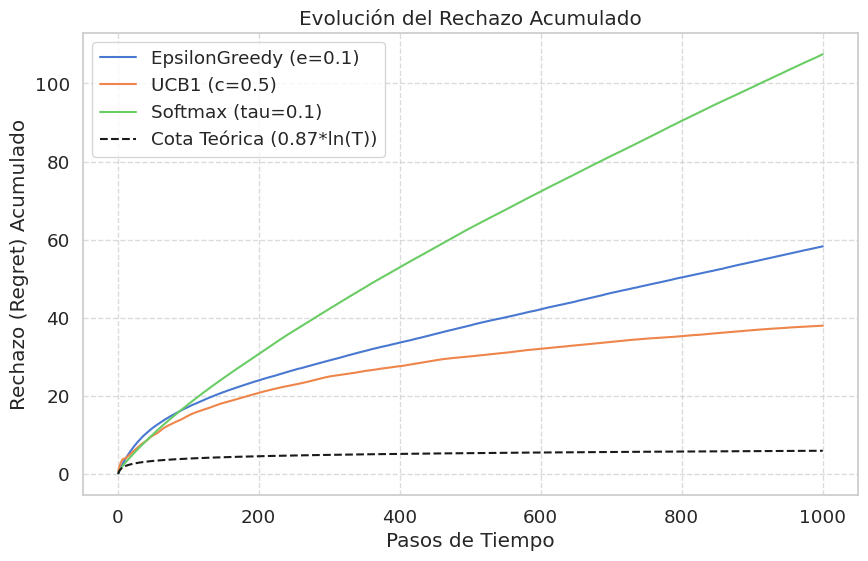

In [20]:
_, optimal_value = bandit.optimal_arm
regret_per_step = optimal_value - rewards_comp
cumulative_regret = np.cumsum(regret_per_step, axis=1)

plot_regret(steps, cumulative_regret, agents_comp, cte=lai_robbins_cte)

Observamos que UCB1 es el que tiene un mejor comportamioento respecto a las mejores versiones de los otros métodos.

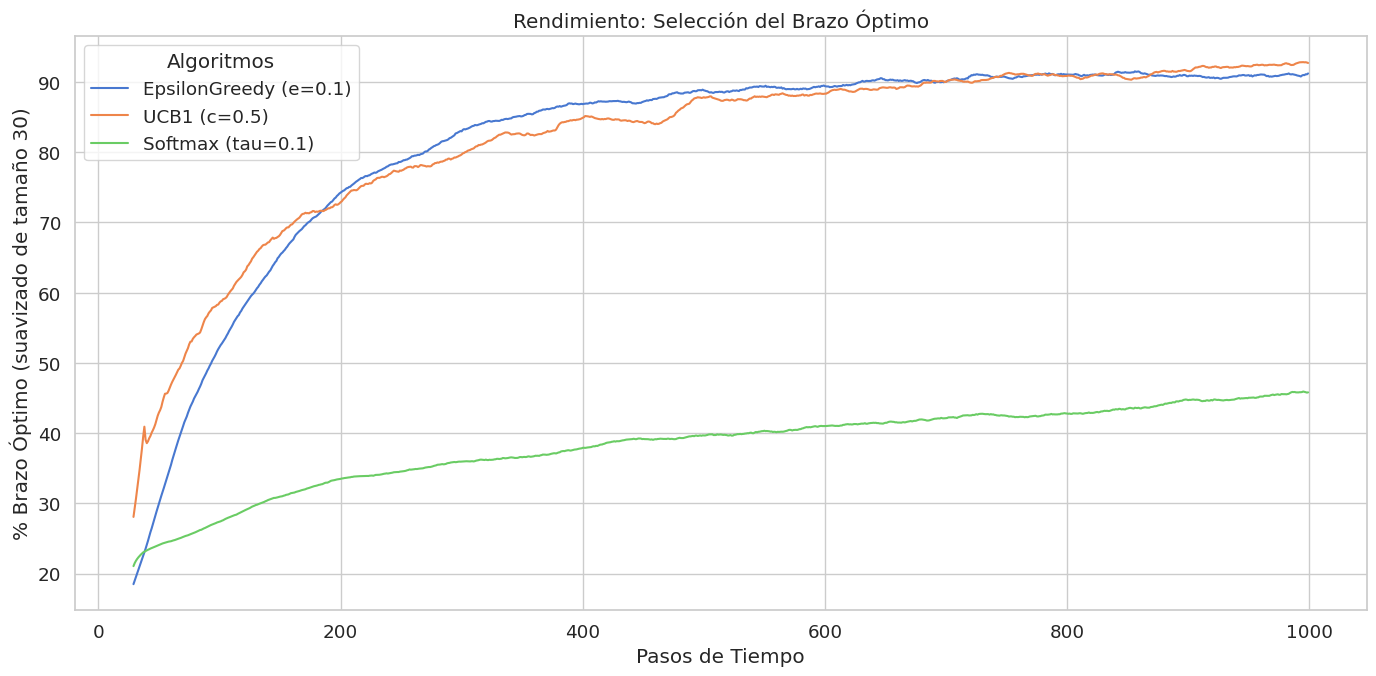

In [23]:
plot_optimal_selections(steps, optimal_comp, agents_comp, window_size=30)

UCB1 es el que mejor converge a una selección optima de forma consistente, softmax es más estable pero acrece de forma más lenta que el epsilon greedy.

#### Análisis Comparativo

La gráfica anterior resume el rendimiento relativo. A continuación, mostramos los valores finales numéricos para una comparación precisa:

In [22]:
_, optimal_value = bandit.optimal_arm
print("{:<15} | {:<15} | {:<15}".format("Algoritmo", "Regret Final", "Selección Óptima %"))
print("-"*55)
for i, agent in enumerate(agents_comp):
    # Calcular regret final acumulado
    regret_final = np.sum(optimal_value - rewards_comp[i])
    print("{:<15} | {:<15.2f} | {:<15.2f}%".format(
        agent.name, 
        regret_final, 
        optimal_comp[i, -1] * 100
    ))

Algoritmo       | Regret Final    | Selección Óptima %
-------------------------------------------------------
EpsilonGreedy (e=0.1) | 58.33           | 93.40          %
UCB1 (c=0.5)    | 38.02           | 91.80          %
Softmax (tau=0.1) | 107.47          | 46.80          %


## 8. Conclusiones
En términos generales, la familia que muestra mayor potencial es UCB. Su capacidad para ajustar implícitamente el balance entre exploración y explotación le permite alcanzar los mejores porcentajes de selección óptima y una convergencia más rápida en los escenarios analizados. Sin embargo, su rendimiento es claramente dependiente del problema: en entornos de baja varianza basta con una exploración reducida, mientras que en problemas con mayor incertidumbre es necesario incrementar el parámetro 𝑐. Esto implica que su desempeño óptimo requiere cierto conocimiento previo de la naturaleza del entorno.

En contraste, Softmax se revela como la familia más difícil de regular. Pequeñas variaciones en la temperatura provocan cambios muy bruscos en el comportamiento del algoritmo, pasando de una explotación prematura a una exploración excesiva. Aunque en algunos casos puede presentar un regret competitivo, su bajo porcentaje de selección óptima y su alta sensibilidad al parámetro 𝜏 hacen que, en conjunto, obtenga resultados menos satisfactorios y menos robustos que las otras alternativas.

Por su parte, la familia ϵ-greedy mejora significativamente al incorporar un mecanismo de decaimiento. Esta variante logra un comportamiento más estable y una mejora progresiva en el tiempo en los distintos escenarios planteados. Sin alcanzar los picos de rendimiento de UCB, ofrece una solución polivalente, menos dependiente de información previa y con una evolución constante. En horizontes temporales cortos, UCB resulta preferible por su rápida convergencia; sin embargo, a largo plazo, la elección entre ambas familias puede resultar más debatible, ya que ϵ-greedy con decaimiento mantiene una evolución estable y sostenida.